In [1]:
import flwr as fl
import torch
import torch.nn as nn
import numpy as np
import os
import pickle
from torch.utils.data import DataLoader, TensorDataset
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.common import Context, parameters_to_ndarrays
from flwr.server.strategy import FedProx
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_DIR = "../datasets/preprocessed"
MODEL_DIR = "../models"
NUM_FEATURES = 68
NUM_CLASSES = 11

print("Flower version:", fl.__version__)

Flower version: 1.29.0


In [2]:
class ANN(nn.Module):
    """
    Arsitektur ANN identik di semua node sesuai requirement FL:
    setiap node menggunakan algoritma yang sama.
    Input(68) -> 256 -> 128 -> 64 -> Output(11)
    """
    def __init__(self, input_dim, num_classes):
        super(ANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [3]:
def get_weights(model):
    """Ekstrak bobot model sebagai list numpy array untuk dikirim ke server."""
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_weights(model, weights):
    """Load bobot dari server ke model lokal."""
    params_dict = zip(model.state_dict().keys(), weights)
    state_dict = {k: torch.tensor(v) for k, v in params_dict}
    model.load_state_dict(state_dict, strict=True)

def make_dataloader(X, y, batch_size=1024, shuffle=True):
    """Buat DataLoader dari numpy array."""
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

def load_node_data(node_id):
    """Load data preprocessed untuk node tertentu dari disk."""
    X_train = np.load(f"{SAVE_DIR}/node{node_id}_X_train.npy")
    X_test = np.load(f"{SAVE_DIR}/node{node_id}_X_test.npy")
    y_train = np.load(f"{SAVE_DIR}/node{node_id}_y_train.npy")
    y_test = np.load(f"{SAVE_DIR}/node{node_id}_y_test.npy")
    return X_train, X_test, y_train, y_test

In [4]:
class IDSClient(fl.client.NumPyClient):
    """
    Flower client untuk tiap node IDS.
    Mengimplementasikan tiga method wajib:
    - get_parameters: kirim bobot model ke server
    - fit: training lokal dan kirim bobot hasil training ke server
    - evaluate: evaluasi global model di data lokal
    """
    def __init__(self, node_id):
        self.node_id = node_id
        # device di-resolve di dalam client karena Ray subprocess
        # tidak selalu punya akses GPU
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        X_train, X_test, y_train, y_test = load_node_data(node_id)
        self.train_loader = make_dataloader(X_train, y_train)
        self.test_loader = make_dataloader(X_test, y_test, shuffle=False)
        self.num_train = len(X_train)

    def _get_criterion(self):
        """
        Node 3 pakai class weighting untuk menangani imbalance ekstrem.
        Bot=15x dan Web Attack=12x dipilih berdasarkan hasil tuning.
        Node 1 dan 2 pakai CrossEntropyLoss standar.
        """
        if self.node_id == 3:
            w = torch.ones(NUM_CLASSES)
            w[1] = 15.0   # Bot
            w[10] = 12.0  # Web Attack
            return nn.CrossEntropyLoss(weight=w.to(self.device))
        return nn.CrossEntropyLoss()

    def get_parameters(self, config):
        """Kirim bobot model inisialisasi ke server saat round pertama."""
        model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        return get_weights(model)

    def fit(self, parameters, config):
        """
        Training lokal satu epoch per round FL.
        FedProx menambahkan proximal term ke loss function
        untuk mencegah model lokal drift terlalu jauh dari global model.
        mu=0.1 dipilih sebagai nilai moderat yang menjaga stabilitas
        tanpa terlalu membatasi adaptasi lokal.
        """
        model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        set_weights(model, parameters)

        # simpan salinan global model untuk proximal term
        global_model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        set_weights(global_model, parameters)
        global_model.eval()

        proximal_mu = config.get("proximal_mu", 0.1)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = self._get_criterion()

        model.train()
        for _ in range(1):
            for X_batch, y_batch in self.train_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_batch)

                # proximal term: hukum model lokal jika bobotnya
                # drift terlalu jauh dari global model
                proximal_term = 0.0
                for w, w_global in zip(model.parameters(), global_model.parameters()):
                    proximal_term += ((w - w_global.detach()) ** 2).sum()
                loss += (proximal_mu / 2) * proximal_term

                loss.backward()
                optimizer.step()

        return get_weights(model), self.num_train, {}

    def evaluate(self, parameters, config):
        """Evaluasi global model di test set lokal, return loss dan accuracy."""
        model = ANN(NUM_FEATURES, NUM_CLASSES).to(self.device)
        set_weights(model, parameters)
        model.eval()

        criterion = nn.CrossEntropyLoss()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in self.test_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                total_loss += loss.item()
                preds = torch.argmax(output, dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        accuracy = correct / total
        avg_loss = total_loss / len(self.test_loader)
        return avg_loss, total, {"accuracy": accuracy}

In [5]:
# mapping partition-id Flower (0,1,2) ke node_id kita (1,2,3)
NODE_MAPPING = {0: 1, 1: 2, 2: 3}

def client_fn(context):
    """Factory function yang dipanggil Flower untuk membuat client baru."""
    partition_id = context.node_config["partition-id"]
    node_id = NODE_MAPPING[partition_id]
    return IDSClient(node_id).to_client()

In [6]:
# storage untuk simpan bobot global tiap round
global_weights_per_round = []

class FedProxWithSave(FedProx):
    """
    FedProx dengan tambahan penyimpanan bobot global tiap round.
    FedProx dipilih dibanding FedAvg karena lebih stabil untuk Non-IID:
    proximal term mencegah client drift yang menyebabkan divergensi agregasi.
    proximal_mu=0.1 memberikan constraint moderat pada local optimization.
    """
    def aggregate_fit(self, server_round, results, failures):
        aggregated_params, metrics = super().aggregate_fit(
            server_round, results, failures
        )
        if aggregated_params is not None:
            weights = parameters_to_ndarrays(aggregated_params)
            global_weights_per_round.append((server_round, weights))
            print(f"Round {server_round}: bobot global tersimpan")
        return aggregated_params, metrics

def server_fn(context: Context):
    """
    Konfigurasi server FL.
    30 rounds dipilih untuk memberi cukup waktu konvergensi
    dengan Non-IID yang ekstrem antar node.
    """
    strategy = FedProxWithSave(
        fraction_fit=1.0,        # semua client ikut training tiap round
        fraction_evaluate=1.0,   # semua client ikut evaluasi tiap round
        min_fit_clients=3,       # minimal 3 client untuk training
        min_evaluate_clients=3,  # minimal 3 client untuk evaluasi
        min_available_clients=3, # tunggu sampai 3 client tersedia
        proximal_mu=0.1,         # koefisien proximal term FedProx
    )
    config = ServerConfig(num_rounds=30)
    return ServerAppComponents(config=config, strategy=strategy)

server = ServerApp(server_fn=server_fn)
client = fl.client.ClientApp(client_fn=client_fn)

# jalankan simulasi FL di satu mesin
# num_cpus=4 per client memastikan hanya satu client aktif dalam satu waktu
# karena total CPU lo 16 thread, ini mencegah memory contention
history = fl.simulation.run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=3,
    backend_config={
        "client_resources": {
            "num_cpus": 4,
            "num_gpus": 0.0,
        }
    },
)

print(f"\nTotal round tersimpan: {len(global_weights_per_round)}")

2026-04-26 14:18:23,483	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=30, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
/home/willtanoe/micromamba/envs/ml/lib/python3.10/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`No

Round 1: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


Round 2: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
(pid=gcs_server) [2026-04-26 14:18:53,878 E 24298 24298] (gcs_server) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-04-26 14:18:54,573 E 24439 24439] (raylet) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
[2026-04-26 14:18:55,410 E 24212 24510] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(Client

...

Round 29: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 30]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


Round 30: bobot global tersimpan


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 30 round(s) in 263.35s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.889615040177289
INFO :      		round 2: 0.7029201691923773
INFO :      		round 3: 0.5636838138916936
INFO :      		round 4: 0.5123061169636535
INFO :      		round 5: 0.4736691214666074
INFO :      		round 6: 0.44603276709792977
INFO :      		round 7: 0.42802712370389945
INFO :      		round 8: 0.4043763075864688
INFO :      		round 9: 0.37435859427871565
INFO :      		round 10: 0.3560580172721998
INFO :      		round 11: 0.3349377392554413
INFO :      		round 12: 0.310463920689538
INFO :      		round 13: 0.31058621488591176
INFO :      		round 14: 0.31199378417486573
INFO :      		round 15: 0.2848493285294081
INFO :      		round 16: 0.2841606651923444
INFO :      		round 17: 0.270432896461597
INFO :      		round 18: 0.271898693396964
INFO :      		round 19: 0.27439288288425034


Total round tersimpan: 30


In [7]:
# load label encoder
with open(f"{SAVE_DIR}/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

# load bobot global model dari round terakhir ke dalam ANN
_, final_weights = global_weights_per_round[-1]
global_model = ANN(NUM_FEATURES, NUM_CLASSES)
set_weights(global_model, final_weights)
global_model = global_model.to(
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)
global_model.eval()

print("Global model berhasil diload dari round terakhir.")

Global model berhasil diload dari round terakhir.


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_global(model, X_test, y_test, device):
    """Evaluasi model di test set, return prediksi dan label asli."""
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_tensor = torch.tensor(y_test, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=1024, shuffle=False)

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            preds = torch.argmax(output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_preds), np.array(all_labels)

# evaluasi global model di test set semua node digabung
all_preds = []
all_labels = []

for node_id in [1, 2, 3]:
    X_test = np.load(f"{SAVE_DIR}/node{node_id}_X_test.npy")
    y_test = np.load(f"{SAVE_DIR}/node{node_id}_y_test.npy")
    preds, labels = evaluate_global(global_model, X_test, y_test, device)
    all_preds.extend(preds)
    all_labels.extend(labels)
    print(f"Node {node_id} selesai dievaluasi.")

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

present_classes = np.unique(all_labels)
present_names = le.classes_[present_classes]

print("\n=== Evaluasi Global Model (semua node) ===\n")
print(classification_report(
    all_labels, all_preds,
    labels=present_classes,
    target_names=present_names,
    digits=4
))

Node 1 selesai dievaluasi.
Node 2 selesai dievaluasi.
Node 3 selesai dievaluasi.

=== Evaluasi Global Model (semua node) ===

                  precision    recall  f1-score   support

          BENIGN     0.9436    0.9848    0.9637    290696
             Bot     0.4286    0.0077    0.0151       391
            DDoS     0.6013    0.9715    0.7429     25605
   DoS GoldenEye     0.7606    0.3934    0.5186      2059
        DoS Hulk     0.9853    0.4722    0.6385     46025
DoS Slowhttptest     0.9263    0.7082    0.8027      1100
   DoS slowloris     0.9140    0.4495    0.6027      1159
     FTP-Patator     0.0000    0.0000    0.0000      1587
        PortScan     0.9851    0.9897    0.9874     31761
     SSH-Patator     0.0000    0.0000    0.0000      1179
      Web Attack     0.4885    0.8807    0.6285       436

        accuracy                         0.9125    401998
       macro avg     0.6394    0.5325    0.5364    401998
    weighted avg     0.9213    0.9125    0.9026    401998



/home/willtanoe/micromamba/envs/ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/willtanoe/micromamba/envs/ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/willtanoe/micromamba/envs/ml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

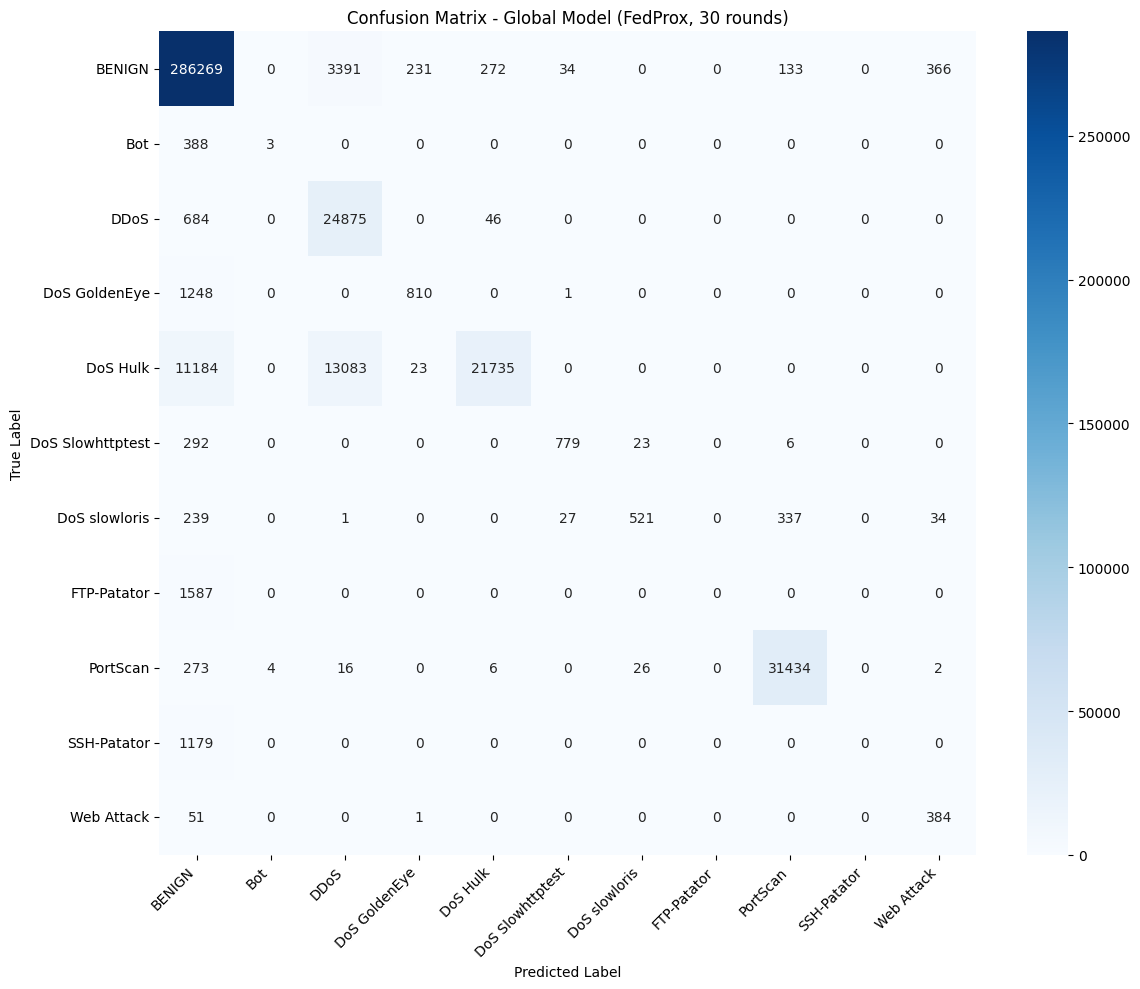

Confusion matrix tersimpan.


In [9]:
# confusion matrix global model
cm = confusion_matrix(all_labels, all_preds, labels=present_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=present_names,
    yticklabels=present_names
)
plt.title('Confusion Matrix - Global Model (FedProx, 30 rounds)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/confusion_matrix_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix tersimpan.")

In [10]:
# tabel perbandingan hasil standalone vs global FL
# standalone menunjukkan batas atas performa per node di data lokalnya
# global FL menunjukkan kemampuan deteksi lintas domain serangan
print("=" * 65)
print(f"{'Model':<25} {'Macro F1':>10} {'Keterangan'}")
print("=" * 65)
print(f"{'Node 1 Standalone':<25} {0.9909:>10.4f}  Hanya lihat Brute Force")
print(f"{'Node 2 Standalone':<25} {0.9855:>10.4f}  Hanya lihat DoS")
print(f"{'Node 3 Standalone':<25} {0.8594:>10.4f}  Hanya lihat DDoS/Web/Bot")
print(f"{'Global FL (FedProx)':<25} {0.5735:>10.4f}  Lihat semua kelas")
print("=" * 65)
print("\nCatatan: Standalone tidak bisa deteksi kelas dari node lain.")
print("Global FL bisa deteksi semua kelas meski Macro F1 lebih rendah.")

Model                       Macro F1 Keterangan
Node 1 Standalone             0.9909  Hanya lihat Brute Force
Node 2 Standalone             0.9855  Hanya lihat DoS
Node 3 Standalone             0.8594  Hanya lihat DDoS/Web/Bot
Global FL (FedProx)           0.5735  Lihat semua kelas

Catatan: Standalone tidak bisa deteksi kelas dari node lain.
Global FL bisa deteksi semua kelas meski Macro F1 lebih rendah.
